# Experiment 2: Effect of Number of Features

## Research Question

How does the number of input features affect the generalization
performance of Linear Regression on the California Housing dataset?

## Hypothesis

Adding informative features will improve predictive performance, but the
benefit may diminish as additional weakly informative or redundant
features are introduced.

## Experimental Principle

Only the number of input features will be changed.

The following will remain constant:

- Training data
- Validation data
- Test data
- Preprocessing strategy
- Linear Regression model
- Random seed
- Evaluation metrics

# Feature Addition Order

## EDA-Based Feature Ranking

According to our Exploratory Data Analysis (EDA), the features should be added to the model incrementally in the following order.

The ordering is based on the absolute correlation of each feature with the target variable, where a higher value indicates a stronger linear relationship with the target.

| Rank | Feature | Correlation |
|------|---------|-------------|
| 1 | `median_income` | 0.688075 |
| 2 | `latitude` | 0.144160 |
| 3 | `total_rooms` | 0.134153 |
| 4 | `housing_median_age` | 0.105623 |
| 5 | `households` | 0.065843 |
| 6 | `total_bedrooms` | 0.049686 |
| 7 | `longitude` | 0.045967 |
| 8 | `population` | 0.024650 |

## Feature Addition Sequence

For the feature addition experiments, features should be introduced cumulatively in this order:

1. `median_income`
2. `latitude`
3. `total_rooms`
4. `housing_median_age`
5. `households`
6. `total_bedrooms`
7. `longitude`
8. `population`

### Experimental Sequence

The experiments should follow this progression:

- **Step 1:** `median_income`
- **Step 2:** `median_income` + `latitude`
- **Step 3:** `median_income` + `latitude` + `total_rooms`
- **Step 4:** Add `housing_median_age`
- **Step 5:** Add `households`
- **Step 6:** Add `total_bedrooms`
- **Step 7:** Add `longitude`
- **Step 8:** Add `population`

## Purpose

This ordering allows us to study how model performance changes as features with progressively weaker relationships with the target are added.

At each step, the previously added features remain unchanged, and only **one new feature** is introduced.

Therefore, the experiment isolates the effect of adding each additional feature on the model's generalization performance.

> **Note:** This ranking is based on the EDA correlation analysis. It represents the strength of the individual linear relationship between each feature and the target, not the feature's guaranteed importance in the final multivariate model.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [44]:
df = pd.read_csv("E:\House Price Prediction ML Project\Data\Raw\housing.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\H'
<>:1: SyntaxWarning: invalid escape sequence '\H'
C:\Users\HP\AppData\Local\Temp\ipykernel_29892\4013469833.py:1: SyntaxWarning: invalid escape sequence '\H'
  df = pd.read_csv("E:\House Price Prediction ML Project\Data\Raw\housing.csv")


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [45]:
X = df.drop(columns=["median_house_value"])
y =df['median_house_value']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

#Split the raw data inot train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

#Seprate Numerical Features and Categorical Feature
numerical_features = X_train.select_dtypes(include=('int64', 'float64')).columns
categorical_features = X_train.select_dtypes(include=('str','object')).columns


In [47]:
X_train_pool, X_val, y_train_pool, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

#x_train_pool, y_train_pool -> 80% of original training data, used to train machine learning model.
#x_val, y_val -> 20% of original training data (test_size=0.20), held back to tune hyperparameters and evaluate performance before final testing.


### 1. Recalculate feature ranking

In [71]:
feature_target_corr = (
    X_train_pool.select_dtypes(include='number').corrwith(y_train_pool).abs().sort_values(ascending=False)
)

feature_target_corr

median_income         0.684367
latitude              0.144429
total_rooms           0.136186
housing_median_age    0.113771
households            0.069842
total_bedrooms        0.053088
longitude             0.047291
population            0.020046
dtype: float64

In [72]:
feature_order = feature_target_corr.index.tolist()

feature_order  #use this ranking for experiment

['median_income',
 'latitude',
 'total_rooms',
 'housing_median_age',
 'households',
 'total_bedrooms',
 'longitude',
 'population']

### 2. Define the feature subsets

In [ ]:
feature_order = [
    "median_income",
    "latitude",
    "total_rooms",
    "housing_median_age",
    "households",
    "total_bedrooms",
    "longitude",
    "population"
]

features_set = []

for i in range(1, len(feature_order) + 1):
    features_set.append(feature_order[:i])

In [79]:
for i, item in enumerate(features_set):
    print(i + 1, item, type(item))

1 ['median_income'] <class 'list'>
2 ['median_income', 'latitude'] <class 'list'>
3 ['median_income', 'latitude', 'total_rooms'] <class 'list'>
4 ['median_income', 'latitude', 'total_rooms', 'housing_median_age'] <class 'list'>
5 ['median_income', 'latitude', 'total_rooms', 'housing_median_age', 'households'] <class 'list'>
6 ['median_income', 'latitude', 'total_rooms', 'housing_median_age', 'households', 'total_bedrooms'] <class 'list'>
7 ['median_income', 'latitude', 'total_rooms', 'housing_median_age', 'households', 'total_bedrooms', 'longitude'] <class 'list'>
8 ['median_income', 'latitude', 'total_rooms', 'housing_median_age', 'households', 'total_bedrooms', 'longitude', 'population'] <class 'list'>


### 3. Run the experiment

In [93]:
from sklearn.base import clone
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

results = []
for input_var in features_set:
    # Select only the features for this experiment
    X_train_subset = X_train_pool[input_var]
    X_val_subset = X_val[input_var]

    # Create preprocessing + model for this feature subset
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    # Train
    model.fit(X_train_subset, y_train_pool)

    # Predictions
    y_train_pred = model.predict(X_train_subset)
    y_val_pred = model.predict(X_val_subset)

    # Metrics
    train_rmse = root_mean_squared_error(y_train_pool, y_train_pred)
    val_rmse = root_mean_squared_error(y_val, y_val_pred)

    train_mae = mean_absolute_error(y_train_pool, y_train_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)

    train_r2 = r2_score(y_train_pool, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)

    # Store results
    results.append({
        "Number of Features": len(input_var),
        "Features": ','.join(input_var),
        "Train_RMSE": train_rmse,
        "Val_RMSE": val_rmse,
        "Train_MAE": train_mae,
        "Val_MAE": val_mae,
        "Train_r2_Score": train_r2,
        "Val_r2_Score": val_r2,
    })

In [94]:
results_df = pd.DataFrame(results)
results_df

,Number of Features,Features,Train_RMSE,Val_RMSE,Train_MAE,Val_MAE,Train_r2_Score,Val_r2_Score
0,1,median_income,83911.146512,82905.552953,62743.763107,62079.419197,0.468358,0.474870
1,2,"median_income,latitude",83264.973872,82311.262850,62197.784355,61403.514042,0.476515,0.482371
2,3,"median_income,latitude,total_rooms",83264.741931,82309.660808,62195.237044,61401.410291,0.476518,0.482391
3,4,"median_income,latitude,total_rooms,housing_med...",79877.223689,79430.618950,59751.354853,58840.215953,0.518246,0.517968
4,5,"median_income,latitude,total_rooms,housing_med...",78134.199830,77977.072187,58093.105271,57329.641979,0.539041,0.535449
5,6,"median_income,latitude,total_rooms,housing_med...",77635.259083,77314.383258,57509.065197,56649.835057,0.544909,0.543311
6,7,"median_income,latitude,total_rooms,housing_med...",72125.328892,70967.985023,53106.313012,52261.801662,0.607215,0.615209
7,8,"median_income,latitude,total_rooms,housing_med...",69596.371743,68582.469250,50960.916093,50182.988812,0.634276,0.640643


### 4. Plot feature count vs validation RMSE


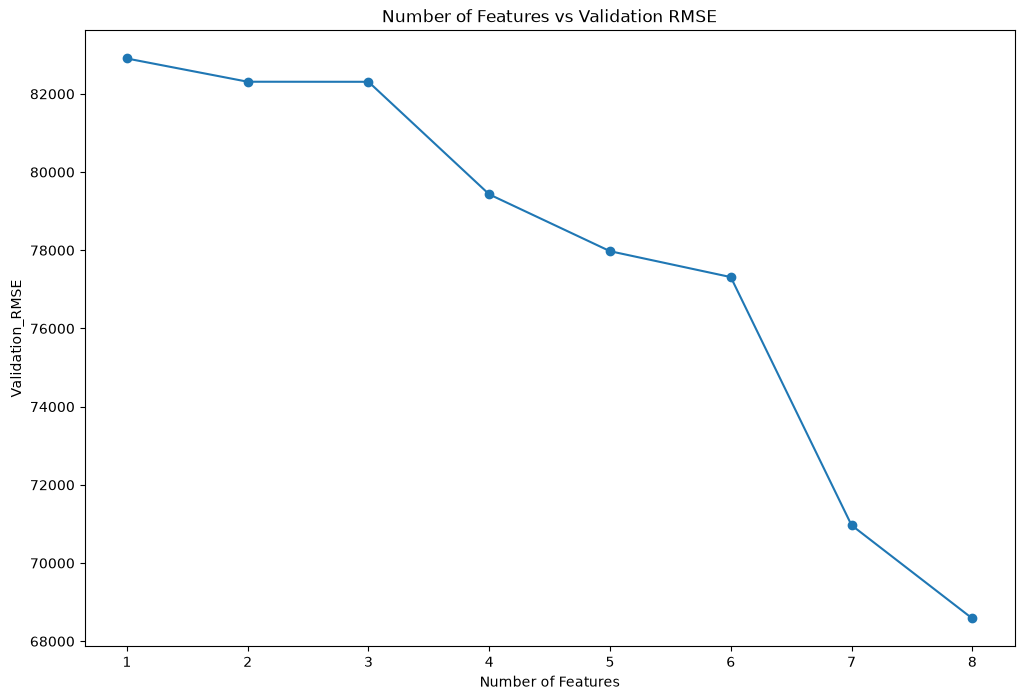

In [95]:
plt.figure(figsize=(12,8))

plt.plot(
    results_df['Number of Features'],
    results_df['Val_RMSE'],
    marker = 'o'
)

plt.xlabel("Number of Features")
plt.ylabel("Validation_RMSE")
plt.title("Number of Features vs Validation RMSE")
plt.show()

### 5. Feature Count vs r2_Score


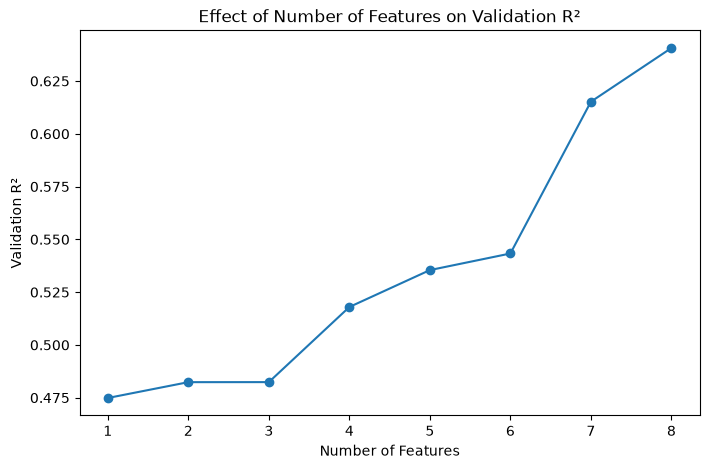

In [96]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Number of Features"],
    results_df["Val_r2_Score"],
    marker="o"
)

plt.xlabel("Number of Features")
plt.ylabel("Validation R²")
plt.title("Effect of Number of Features on Validation R²")

plt.show()

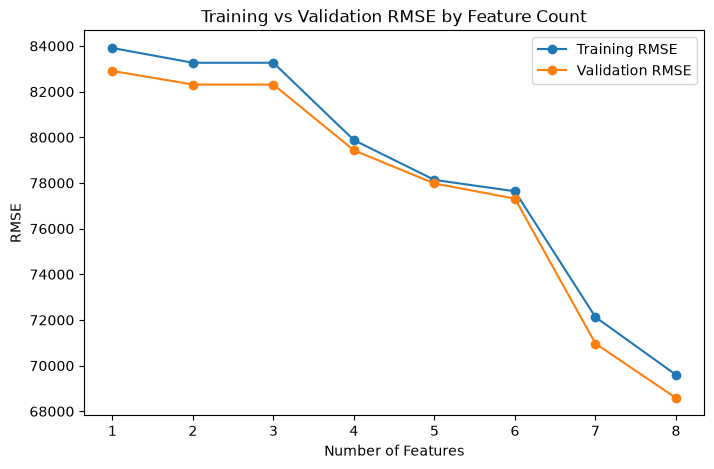

In [97]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Number of Features"],
    results_df["Train_RMSE"],
    marker="o",
    label="Training RMSE"
)

plt.plot(
    results_df["Number of Features"],
    results_df["Val_RMSE"],
    marker="o",
    label="Validation RMSE"
)

plt.xlabel("Number of Features")
plt.ylabel("RMSE")
plt.title("Training vs Validation RMSE by Feature Count")
plt.legend()

plt.show()

## 6. Experiment Results

The results show that increasing the number of input features generally
improves the predictive performance of Linear Regression.

Validation RMSE decreased from approximately 82,906 with one feature to
68,582 with all eight features. At the same time, validation R² increased
from approximately 0.475 to 0.641.

However, the contribution of individual features was not uniform. For
example, adding `total_rooms` after `median_income` and `latitude`
produced almost no additional improvement in validation performance,
whereas later feature additions produced substantially larger
improvements.

Therefore, the results suggest that increasing the number of features
can improve predictive performance, but the predictive value of
individual features varies considerably.

## 7. Hypothesis Evaluation

### H2: Effect of Feature Information

**Hypothesis:** Adding informative features will improve predictive
performance, but the benefit may diminish as additional weakly
informative or redundant features are introduced.

**Result:** Partially supported.

Increasing the number of features generally improved validation
performance. However, the improvement was not uniform across feature
additions. Some features produced very small changes, while other
features produced substantial improvements.

The results indicate that the number of features alone does not determine
performance. The information contained in the selected features also
plays an important role.